<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy, UCB y softmax en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.


## Preparación del entorno


In [ ]:
import numpy as np
from typing import List
 
from src.agents import Agent, EpsilonGreedyAgent, UCBAgent, SoftmaxAgent 
from src.arms import ArmNormal, Bandit
from src.plotting import plot_optimal_selections, plot_regret

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

In [2]:

def run_experiment(bandit: Bandit, agents: List[Agent], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(agents), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(agents), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in agents:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(agents)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(agents):
                chosen_arm = algo.get_action() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

    rewards /= runs
    optimal_selections /= runs

    return rewards, optimal_selections


## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. 

In [ ]:
k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


### Experimento con epsilon-greedy
Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [4]:
# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
agents = [EpsilonGreedyAgent(k_arms=k, epsilon=0), EpsilonGreedyAgent(k_arms=k, epsilon=0.01), EpsilonGreedyAgent(k_arms=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, agents, steps, runs)

#### Visualización de los resultados con epsilon-greedy

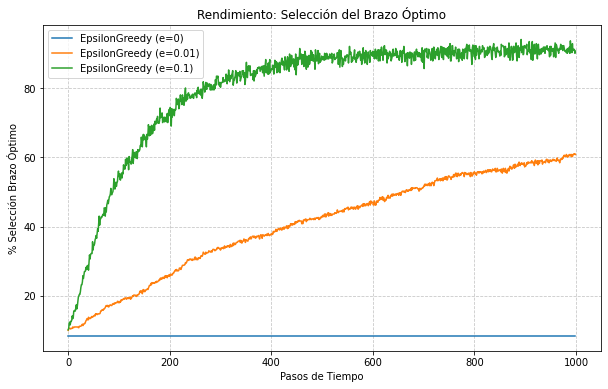

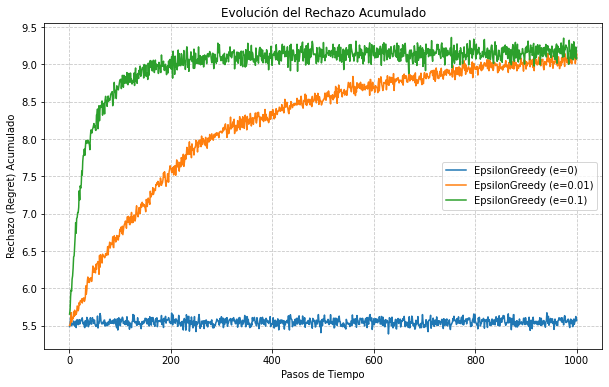

In [ ]:
# Graficar los resultados
plot_optimal_selections(steps, optimal_selections, agents)
plot_regret(steps, rewards, agents)

## Análisis detallado de Epsilon Greedy

### Selección del brazo óptimo

Aquí se comparan distintos valores de ϵ:

- ε = 0 (azul): Estrategia puramente explotadora. Se queda prácticamente fija en un brazo desde el inicio (≈10%), sin capacidad de corregir errores iniciales.

- ε = 0.01 (naranja): Introduce una pequeña exploración. Mejora progresivamente, pero la convergencia es lenta.

- ε = 0.1 (verde): Explora más agresivamente. Aprende mucho más rápido y alcanza valores cercanos al 90–95% de selección óptima.


### Rechazo acumulado (Regret)

- ε = 0: presenta el menor regret acumulado, pero esto se debe a que deja de explorar muy pronto (aunque pueda estar equivocado).

- ε = 0.01: muestra un crecimiento moderado del regret.

- ε = 0.1: tiene el mayor regret acumulado, ya que sigue explorando constantemente (10% del tiempo).

---





### Experimento con UCB
Se contrastan 3 algoritmos UCB para valores c: 0.0, 1.0, y 2.0.

In [6]:
# Definir los algoritmos a comparar. En este caso son 3 algoritmos UCB con diferentes valores de c.
agents = [UCBAgent(k_arms=k, c=0.5), UCBAgent(k_arms=k, c=1.0), UCBAgent(k_arms=k, c=2.0), UCBAgent(k_arms=k, c=4.0)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, agents, steps, runs)

#### Visualización de los resultados con UCB

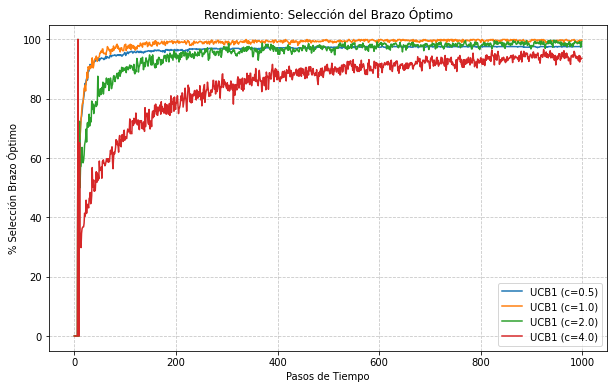

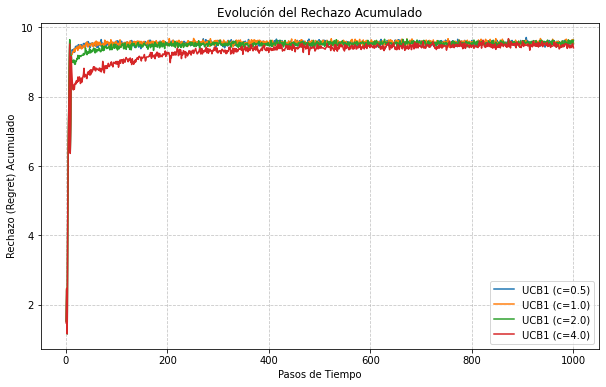

In [ ]:
# Graficar los resultados
plot_optimal_selections(steps, optimal_selections, agents)
plot_regret(steps, rewards, agents)

## Análisis detallado de UCB1

### Selección del brazo óptimo

Las curvas representan distintos valores del parámetro c, que controla la intensidad de la exploración:

- c = 0.5 (azul): Explora poco y converge muy rápidamente hacia el brazo óptimo, alcanzando casi el 100% en pocos pasos.

- c = 1.0 (naranja): Presenta un equilibrio excelente entre exploración y explotación. La convergencia es muy rápida y estable.

- c = 2.0 (verde): Explora más agresivamente. Aunque tarda ligeramente más en estabilizarse, también alcanza valores cercanos al óptimo.

- c = 4.0 (rojo): Explora en exceso al inicio, lo que ralentiza la convergencia. Sin embargo, con el tiempo también se aproxima al 100%.



### Rechazo acumulado (Regret)

Todas las curvas crecen rápidamente al inicio (fase obligatoria de exploración).

Posteriormente, el crecimiento del regret se estabiliza.

Valores más altos de c tienden a presentar un ligero incremento adicional en el regret debido a mayor exploración.

---

### Experimento con softmax
Se contrastan 3 algoritmos softmax para valores tau: 0.1, 0.5, y 1.0.

In [8]:
# Definir los algoritmos a comparar. En este caso son 4 algoritmos softmax con diferentes valores de temperatura.
agents = [SoftmaxAgent(k_arms=k, temperature=0.01), SoftmaxAgent(k_arms=k, temperature=0.1), SoftmaxAgent(k_arms=k, temperature=0.5), SoftmaxAgent(k_arms=k, temperature=1.0)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, agents, steps, runs)

#### Visualización de los resultados con softmax

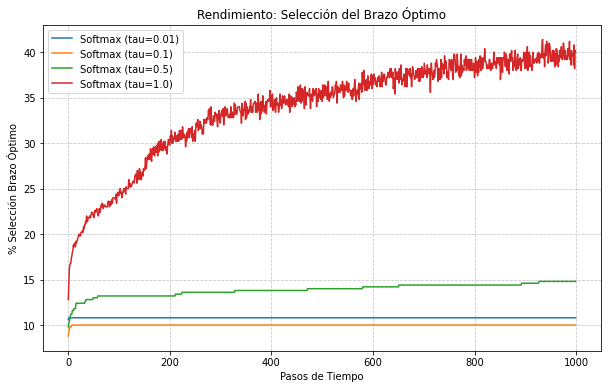

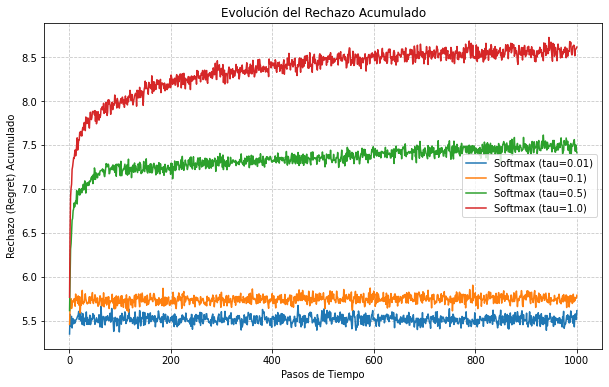

In [ ]:
# Graficar los resultados
plot_optimal_selections(steps, optimal_selections, agents)
plot_regret(steps, rewards, agents)

## Análisis detallado de Softmax

### Selección del brazo óptimo

Las cuatro curvas representan distintos niveles de exploración:

- Azul (t = 0.01): Temperatura muy baja → comportamiento casi determinista. La curva se mantiene prácticamente plana alrededor del 10–11%, lo que indica que el algoritmo se queda atrapado rápidamente en un brazo subóptimo y apenas explora para corregirlo.

- Naranja (t = 0.1): Introduce una ligera exploración, pero sigue siendo insuficiente. El porcentaje de selección óptima apenas mejora respecto a t=0.01, mostrando que el algoritmo sigue explotando demasiado pronto.

- Verde (t = 0.5): Se observa mayor exploración. La curva crece ligeramente más, lo que indica que empieza a descubrir mejores brazos, aunque aún no logra identificar consistentemente el óptimo.

- Rojo (t = 1.0): Es el que más explora. La curva aumenta de forma progresiva hasta alrededor del 40%, mostrando que una mayor temperatura permite descubrir con mayor frecuencia el brazo óptimo.

### Evolución del rechazo acumulado (Regret)

Este gráfico mide el coste de no elegir siempre el brazo óptimo.

- Azul (t = 0.01): Presenta el menor rechazo acumulado. Esto ocurre porque el algoritmo deja de explorar rápidamente, aunque se quede con un brazo subóptimo.

- Naranja (t = 0.1): Tiene un regret ligeramente mayor, debido a una pequeña exploración adicional.

- Verde (t = 0.5): El rechazo acumulado crece más, ya que el algoritmo explora con mayor frecuencia.

- Rojo (t = 1.0): Es el que presenta el mayor rechazo acumulado. Esto se debe a que explora durante más tiempo, lo que implica elegir brazos subóptimos con mayor frecuencia.

---


## Conclusiones

Hemos estudiado un  **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. En este análisis hemos evaluado ε-Greedy, UCB1 y Softmax (Boltzmann), lo que nos permite comparar diferentes estrategias para abordar el dilema clásico de exploración vs explotación.

#### **1. Exploración vs Explotación**
Todos los algoritmos intentan resolver el mismo problema:
Explorar para descubrir nuevas opciones potencialmente mejores.
Explotar el conocimiento actual para maximizar la recompensa inmediata.

##### ε-Greedy
- ε = 0 → Pura explotación. Puede quedar atrapado en un brazo subóptimo.
- ε = 0.01 → Explora poco, mejora lentamente.
- ε = 0.1 → Buen equilibrio, encuentra el óptimo más rápido.

El gráfico muestra claramente que una exploración moderada mejora significativamente el rendimiento.

##### UCB1

UCB1 no explora aleatoriamente, sino que añade un término de incertidumbre que favorece brazos poco probados.
- Valores bajos de c → menos exploración, convergencia rápida.
- Valores altos de c → más exploración, convergencia ligeramente más lenta.

A diferencia de ε-Greedy:
Todas las configuraciones de UCB1 terminan convergiendo cerca del 100% de selección óptima.
La diferencia está en la velocidad de aprendizaje, no en la calidad final.

UCB1 gestiona la exploración de forma más inteligente, priorizando brazos con mayor incertidumbre en lugar de explorar al azar.

##### Softmax (Boltzmann)

Softmax selecciona acciones con probabilidad proporcional a su valor estimado, controlado por la temperatura τ:
- t pequeño → comportamiento casi greedy (poca exploración).
- t grande → mayor aleatoriedad.


En los resultados observamos que:

Temperaturas bajas pueden provocar estancamiento.
Temperaturas altas mejoran la selección óptima, pero aumentan el regret acumulado.

El rendimiento es muy sensible al valor de t.
Softmax depende mucho del ajuste fino del parámetro. Si no está bien calibrado, el rendimiento cae notablemente.

#### **2. Convergencia de los algoritmos**
Los resultados muestran diferencias claras en la velocidad y calidad de convergencia:
- UCB1 → Convergencia más rápida y consistente hacia el brazo óptimo.
- ε-Greedy (ε=0.1) → Buen equilibrio, pero mantiene exploración constante.
- Softmax (t alto) → Aprende, pero de forma menos eficiente y más dependiente del parámetro.

Además, en términos de rechazo (regret) acumulado:
- UCB1 mantiene un crecimiento controlado.
- ε-Greedy con ε alto tiene mayor regret por exploración constante.
- Softmax con t alto presenta el mayor coste acumulado debido a exploración prolongada.


#### **3. Aplicaciones y conclusiones**
En problemas reales como:
- Sistemas de recomendación
- Sistemas de trading automatizado
Es fundamental equilibrar correctamente exploración y explotación.

A partir de los resultados obtenidos:
- ε-Greedy es simple y efectivo, pero puede ser ineficiente si ε no está bien ajustado.
- Softmax ofrece una exploración más gradual, pero es muy sensible al parámetro τ.
- UCB1 demuestra ser la estrategia más robusta y eficiente, ya que explora de forma dirigida y converge rápidamente al óptimo sin necesidad de exploración aleatoria constante.

### **Conclusion final**

El estudio confirma que:
- La falta de exploración conduce a soluciones subóptimas.
- La exploración excesiva aumenta el coste acumulado.
- Un mecanismo de exploración inteligente, como el de UCB1, permite alcanzar un rendimiento superior de forma más estable.

En definitiva, el equilibrio entre exploración y explotación no solo es necesario, sino que la forma en que se implementa marca una diferencia clara en el rendimiento del sistema.